In [100]:
#Lab1A

In [101]:
#1. Setup and Imports
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [102]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [103]:
#3. The Node Class

@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)
    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [104]:
#4. Helper Functions
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions
def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }
def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [105]:
#5. Implementing the Grid Search Problem
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])
    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []
        # 2. For each action in MOVES:
        for action in MOVES:
        #       a. Compute the neighbour cell.
            dr, dc = MOVES[action]
            neighbour = (state[0] + dr, state[1] + dc)
        #       b. Check that it is in bounds.
            if self.in_bounds(neighbour):
        #       c. Check that it is free.
                if self.is_free(neighbour):
        #       d. If valid, add the action name to legal_actions.
                    legal_actions.append(action)
        # 3. Return legal_actions.
        return legal_actions
        raise NotImplementedError("Complete GridProblem.actions")
    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        dr, dc = MOVES[action]
        row, col = state
        # return (row + dr, col + dc)
        return (row + dr, col + dc)
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1


In [106]:
#5.1 Sel-Check for GridProblem

test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [107]:
#6 Sample Drone Map

sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [108]:
#7. Visualisation Helper

def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)
    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)
            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

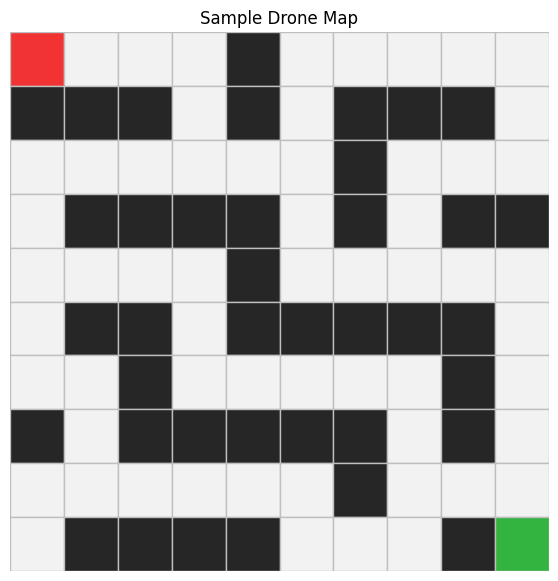

In [109]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [110]:
#8.The Shared expand Method

class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        s = node.state
        # for each action in problem.ACTIONS(s):
        for action in problem.actions(s):
        #     s_prime <- problem.RESULT(s, action)
            s_prime = problem.result(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
            yield Node(state = s_prime, parent = node, action = action, path_cost = cost)


    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [111]:
#9. Breadth-First Search

class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        initial_node = Node(state = problem.initial_state())
        # 2. If the initial state is the goal, return success.
        if problem.initial_state() == problem.goal:
            return SearchResult(algorithm, "Success", initial_node, 0, 0)
        # Initialize metrics
        nodes_expanded = 0
        # 3. Create a deque frontier and add the initial node.
        frontier = deque([initial_node])
        max_frontier_size = len(frontier)
        # 4. Create a reached set and add the initial state.
        reached = {problem.initial_state()}
        # 5. While frontier is not empty:
        while frontier:
        #       a. pop from the LEFT of the deque.
            node = frontier.popleft()
        #       b. increment nodes_expanded.
            nodes_expanded += 1
        #       c. expand the node.
            # node_children = self.expand(problem, node) # This line was not used, removed.
        #       d. for each child:
            for child in self.expand(problem, node):
        #            i. if child is goal, return success.
                if problem.is_goal(child.state):
                    return SearchResult(algorithm, "Success", child, nodes_expanded, max_frontier_size) # return child if it's the goal
        #           ii. if child.state is not in reached:
                if child.state not in reached:
        #                  add child.state to reached.
                    reached.add(child.state)
        #                  append child to frontier.
                    frontier.append(child)
        #       e. update max_frontier_size.
            max_frontier_size = max(max_frontier_size, len(frontier))
        # 6. Return failure if no solution is found.
        return SearchResult(algorithm, "Failure", None, nodes_expanded, max_frontier_size)

In [119]:
#10. Depth-First Search

class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        initial_node = Node(state = problem.initial_state())
        # 2. If the initial state is the goal, return success.
        if problem.initial_state() == problem.goal:
            return SearchResult(algorithm, "Success", initial_node, 0,0)
        # 3. Use a Python list as the stack frontier.
        frontier = [initial_node]
        # 4. Use a reached set.
        reached = {problem.initial_state()}
        # 5. While frontier is not empty:
        nodes_expanded = 0
        max_frontier_size = len(frontier)
        while frontier:
        #       a. pop from the end of the list.
            node = frontier.pop()
        #       b. increment nodes_expanded.
            nodes_expanded += 1
        #       c. expand the node.
            node_children = self.expand(problem, node)
        #       d. add unreached children to the stack
            for child in self.expand(problem, node):
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
        #       e. update max_frontier_size.
            max_frontier_size = max(max_frontier_size, len(frontier))
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.
        for child in reversed(list(self.expand(problem, node))):
            frontier.append(child)
        # 6. Return failure if no solution is found.
        return SearchResult(algorithm, "Failure", None, nodes_expanded, max_frontier_size)



In [121]:
#11. Depth-Limited Search

class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        max_stack_size = 0
        # 1. If node.state is goal, return (node, "success").
        if problem.is_goal(node.state):
            return(node, "success")
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        elif node.depth >= limit:
            return (None, "cutoff")
        # 3. Otherwise:
        else:
        #       a. increment metrics["nodes_expanded"].
            metrics["nodes_expanded"] += 1
        #       b. set cutoff_occurred = False.
            cutoff_occured = False
        #       c. for each child in expand(problem, node):
            for child in self.expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
                if child.state == node.state or (node.parent and child.state == node.parent.state):
                    continue
        #            ii. update max_stack_size.
                max_stack_size = max(max_stack_size, current_stack_size + 1)
        #           iii. recursively call _recursive_dls on the child.
                result, status = self._recursive_dls(problem, child, limit, metrics, current_stack_size + 1)
        #            iv. if result is "success", return success immediately.
                if status == "success":
                    return result, status
        #             v. if result is "cutoff", set cutoff_occurred = True.
                if result == "cutoff":
                    cutoff_occured = True
        #       d. after all children:
        #           if cutoff_occurred, return (None, "cutoff")
        #           else return (None, "failure")
            if cutoff_occured:
              return (None, "cutoff")
            else:
              return (None, "failure")


In [114]:
#12. Iterative Deepening Search

class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        iteration_log = []
        # 2. Accumulate total nodes expanded across all DLS iterations.
        total_nodes_expanded = 0
        # 3. Track the maximum stack size seen in any DLS run.
        max_stack_size = 0
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        for limit in range(max_depth):
            dls = DepthLimitedSearch()
            result = dls.search(problem, limit = limit)
            status = result.status
            iteration_log.append(result)

            if status == "success":
                return SearchResult(algorithm, "Success", result.solution, total_nodes_expanded, max_stack_size)
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
            if status == "failure":
                return SearchResult(algorithm, "Failure", None, total_nodes_expanded, max_stack_size)
        # 6. If all limits return cutoff up to max_depth, return cutoff.
            return SearchResult(algorithm, "Cutoff", None, total_nodes_expanded, max_stack_size)
        return "cuttoff"
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)


In [122]:
#13. Run the Algorithms on the Sample Map

bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,Success,NaN,18.0,18.0,50,5,0
1,DFS,Failure,NaN,NaN,NaN,61,7,0
2,DLS,failure,10.0,NaN,NaN,16,1,0
3,IDS,Cutoff,NaN,NaN,NaN,0,0,0


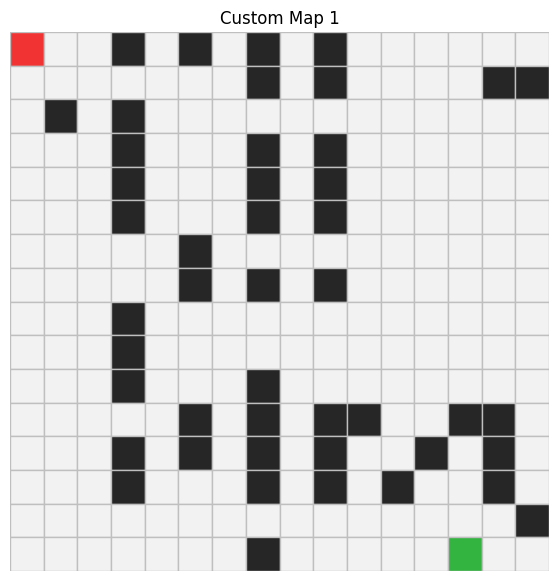

In [144]:
#14. Create Your Own Maps

# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    # Replace this with your own grid.
    [0,0,0,1,0,1,0,1,0,1,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,1],
    [0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0],
    [0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0],
    [0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0],
    [0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,1,0,1,0,1,1,0,0,1,1,0],
    [0,0,0,1,0,1,0,1,0,1,0,0,1,0,1,0],
    [0,0,0,1,0,0,0,1,0,1,0,1,0,0,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],
    [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
]

custom_start_1 = (0,0)
custom_goal_1 = (15,13)

# Example after completing:
# custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
# custom_results_1 = [
custom_results_1 = [
#     bfs.search(custom_problem_1),
    bfs.search(custom_problem_1),
#     dfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
#     dls.search(custom_problem_1, limit=20),
    dls.search(custom_problem_1, limit = 20),
#     ids.search(custom_problem_1, max_depth=40),
    ids.search(custom_problem_1, max_depth = 40)
# ]
]
# show_results(custom_results_1)
show_results(custom_results_1)
plot_path(custom_grid_1, custom_start_1, custom_goal_1, title="Custom Map 1")

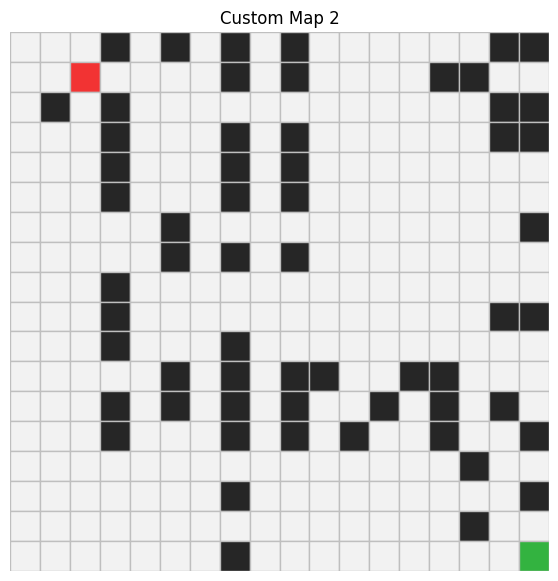

In [146]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    # Replace this with your own grid.
    [0,0,0,1,0,1,0,1,0,1,0,0,0,0,0,0,1,1],
    [0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,1,0,0],
    [0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1],
    [0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1,1],
    [0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0],
    [0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1],
    [0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1],
    [0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,1,0,1,0,1,1,0,0,1,1,0,0,0],
    [0,0,0,1,0,1,0,1,0,1,0,0,1,0,1,0,1,0],
    [0,0,0,1,0,0,0,1,0,1,0,1,0,0,1,0,0,1],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
    [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
    [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
]

custom_start_2 = (1,2)
custom_goal_2 = (17,17)

# Example after completing:
# custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
# custom_results_2 = [
custom_results_2 = [
#     bfs.search(custom_problem_2),
    bfs.search(custom_problem_2),
#     dfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
#     dls.search(custom_problem_2, limit=20),
    dls.search(custom_problem_2, limit = 20),
#     ids.search(custom_problem_2, max_depth=40),
    ids.search(custom_problem_2, max_depth = 40)
# ]
]
# show_results(custom_results_2)
show_results(custom_results_2)
plot_path(custom_grid_2, custom_start_2, custom_goal_2, title="Custom Map 2")

In [126]:
#15 Reflection Questions

In [129]:
#15.1 Problem Formulation

"""1.A state is the current position of the agent on the map represented by a grid cell(row, column)

   2. An action is a move that an agent can take from one state to another or from one cell to another. In this case, actions we have are
     UP, DOWN, LEFT, and RIGHT. So these are actions an agent can use moving from one cell to another.

   3. The result function takes a state and an action and returns the new state reached after applying that action.
      For instance, if the agent is at (1,1) and chooses RIGHT, then the result function returns (1,2) as the next state.

   4. Separating the problem definition from the search algorithm makes search algorithms reusable. The BFS, DFS, DLS, and IDS algorithms
      we have can solve different problems as long as each problem provides its states, actions, result and goal."""

'1.A state is the current position of the agent on the map represented by a grid cell(row, column)\n\n   2. An action is a move that an agent can take from one state to another or from one cell to another. In this case, actions we have are \n     UP, DOWN, LEFT, and RIGHT. So these are actions an agent can use moving from one cell to another.\n\n   3. The result function takes a state and an action and returns the new state reached after applying that action.\n      For instance, if the agent is at (1,1) and chooses RIGHT, then the result function returns (1,2) as the next state.\n\n   4. Separating the problem definition from the search algorithm makes search algorithms reusable. The BFS, DFS, DLS, and IDS algorithms\n      we have can solve different problems as long as each problem provides its states, actions, result and goal.'

In [132]:
#15.2 BFS

"""1. BFS uses FIFO(First In First Out) queue so that states are explores in the order they are discovred. This allows BFS to visit all states at one depth level before moving to the next level
      for instance, if the agent starts at (0,0), BFS first explores all states that are 1 move away such as (0,1) and (1,0), before exploring that are 2 moves away. The first state added to the queue is the first one removed and expanded.

   2. In an unweighted grid, every move has the same cost. BFS explores states level by level, so the first time it reaches the gaol, it has found the path with the fewest moves.

   3. The reached set keeps track of states that have already been visited. This prevents BFS from revisiting the same state multiple times, reducing unnecessary work and avoiding loops.
      for instance, if the agent moves from (0,0) to (0,1), it could potentially move back to (0,0) again. Without the rached set, BFS might keep exploring the same locations repeatedly.
      However, with reached, when BFS encounters (0,0) again, it sees that the states is already in reached and skips it. This makes the search more efficient and ensures eah state is expored only once.
      """

'1. BFS uses FIFO(First In First Out) queue so that states are explores in the order they are discovred. This allows BFS to visit all states at one depth level before moving to the next level\n      for instance, if the agent starts at (0,0), BFS first explores all states that are 1 move away such as (0,1) and (1,0), before exploring that are 2 moves away. The first state added to the queue is the first one removed and expanded.\n\n   2. In an unweighted grid, every move has the same cost. BFS explores states level by level, so the first time it reaches the gaol, it has found the path with the fewest moves.\n   \n   3. The reached set keeps track of states that have already been visited. This prevents BFS from revisiting the same state multiple times, reducing unnecessary work and avoiding loops.\n      for instance, if the agent moves from (0,0) to (0,1), it could potentially move back to (0,0) again. Without the rached set, BFS might keep exploring the same locations repeatedly.\n   

In [131]:
#15.3

"""1. DFS uses a stack also known as(Last In First Out) so that the most recently discovered state is explored first. This allows DFS to follow one path as deeply as possible before backtracking.
     For instance, starting from (0,0), suppose DFS can move to (0,1) and (1,0). If (1,0) is added last, it will be explored first. DFS may continue along that path until it reaches the goal or a dead end before returning to explore other branches.

    2. No, DFS is not guaranteed to find the shortest path. It returns the first solution it finds, even if a shorter path exists elsewhere in the search space.
      For instance, In our grid, there may be a path from (0,0) to (2,2) that takes 4 moves and another that takes 8 moves. DFS might follow the longer path first and return it without ever checking the shorter one.

    3. DFS uses less memory when the search spece is large because it only stores the current path and a few unexplored nodes, while BFS stores all nodes at the current depth level.
      For instance, our grid is very large, BFS may have keep hundreds of states in its frontier at once. DFS stores the states along its current path from the start node, so its memory usage is usually much smaller.

    4. DFS performs poorly when it follows a very deep or unproductive path before exploring other possibilities. It can spend a lot of time searching in the wrong direction.
      For instance, if the goal is near (0,0) but DFS keeps moving deeper into another part of the grid, it may explore may unnecessary states before finding the goal. In very large search spaces, DFS can waste significant time exploring long branches that do not lead to a solution."""

'1. DFS uses a stack also known as(Last In First Out) so that the most recently discovered state is explored first. This allows DFS to follow one path as deeply as possible before backtracking.\n     For instance, starting from (0,0), suppose DFS can move to (0,1) and (1,0). If (1,0) is added last, it will be explored first. DFS may continue along that path until it reaches the goal or a dead end before returning to explore other branches.\n     \n    2. No, DFS is not guaranteed to find the shortest path. It returns the first solution it finds, even if a shorter path exists elsewhere in the search space.\n      For instance, In our grid, there may be a path from (0,0) to (2,2) that takes 4 moves and another that takes 8 moves. DFS might follow the longer path first and return it without ever checking the shorter one.\n      \n    3. DFS uses less memory when the search spece is large because it only stores the current path and a few unexplored nodes, while BFS stores all nodes at the 

In [133]:
#15.4

"""1. If the depth limit is smaller than the depth of the goal, DLS will not be able to reach the goal and will stop searching when the limit is reached.
    For instance, In our grid, suppose the shortest path from (0,0) to (2,2) requires 4 moves. If we run dls.search(problem, limit =2), DLS can only explore states up to depth 2, so it will never reach (2,2) and will not find a solution.

   2. A cutoff means that DLS stopped exploring a path because it reached the specified depth limit, not because it proved that no solution exists.
    For instance, If the search reaches a node at depth 10 and limit is 10, DLS does not expand that node's children. Instead, it returns a cutoff, indicationg that deeper nodes were not explored.

   3. Both DLS and DFS explore nodes depth-first, but DLS has a maximum depth that is allwed to explore, while DFS has no such restriction.
    For instance, DFS may continue exploring deeper and deeper paths until it finds the gaol.
    DLS with limit = 3 will stop exploring any path once depth 3 is reached. This depth limit hepls prevent search from going too deep into unproductive branches.

    4. Path-cycle checking prevents the search from revisiting states that already appear on the current path. This avoids getting stuck in loops and wasting time exploring the same states repeatedly.
      For instance, suppose the agent moves form (0,0) to (0,1) to (0,0) to (0,1) and so on... . Without path-cycle checking, DLS could keep revisiting these states and never make progress. By checking whether a state already exists on the current path, DLS skips that move and continue exploring new states instead."""

"1. If the depth limit is smaller than the depth of the goal, DLS will not be able to reach the goal and will stop searching when the limit is reached.\n    For instance, In our grid, suppose the shortest path from (0,0) to (2,2) requires 4 moves. If we run dls.search(problem, limit =2), DLS can only explore states up to depth 2, so it will never reach (2,2) and will not find a solution.\n   \n   2. A cutoff means that DLS stopped exploring a path because it reached the specified depth limit, not because it proved that no solution exists.\n    For instance, If the search reaches a node at depth 10 and limit is 10, DLS does not expand that node's children. Instead, it returns a cutoff, indicationg that deeper nodes were not explored.\n    \n   3. Both DLS and DFS explore nodes depth-first, but DLS has a maximum depth that is allwed to explore, while DFS has no such restriction.\n    For instance, DFS may continue exploring deeper and deeper paths until it finds the gaol.\n    DLS with l

In [134]:
#15.5

"""1. IDS repeats DLS with increasing depth limit so that it can gradually search deeper levels until the goal is found. This allows IDS to find solutions that may be beyond a small depth limit while still using the low mwmory of DLS.

   2. A single DLS serch may fail because its depth limit is too small to reach the goal. IDS overcomes this by continously increasing the limit, ensuring that every reachable depth will eventually be explored.
     For instance if the goal is 4 moves away from (0,0), DLS with limit = 2 connot find it. However, IDS will eventually run DLS with limit = 4, allowing it to reach the goal. Therefore, IDS is complete as long as a solution exists within the maximum depth considered.

   3. IDS uses DLS at each iteration, and DLS only stores the current search path and a few additional nodes. BFS, on the other hand, must store all nodes at the current frontier level.
     For instance, In a large grid, BFS may need to keep hundreds of states in memory at once. IDS mainly stores nodes along the current path from (0,0) to the current depth, so its memory usage remains much smaller.

    4. The main cost of IDS is that it revisits nodes near the root many times. Each new depth limit causes the search to start again from the initial state."""

'1. IDS repeats DLS with increasing depth limit so that it can gradually search deeper levels until the goal is found. This allows IDS to find solutions that may be beyond a small depth limit while still using the low mwmory of DLS.\n\n   2. A single DLS serch may fail because its depth limit is too small to reach the goal. IDS overcomes this by continously increasing the limit, ensuring that every reachable depth will eventually be explored.\n     For instance if the goal is 4 moves away from (0,0), DLS with limit = 2 connot find it. However, IDS will eventually run DLS with limit = 4, allowing it to reach the goal. Therefore, IDS is complete as long as a solution exists within the maximum depth considered.\n     \n   3. IDS uses DLS at each iteration, and DLS only stores the current search path and a few additional nodes. BFS, on the other hand, must store all nodes at the current frontier level.\n     For instance, In a large grid, BFS may need to keep hundreds of states in memory a

In [135]:
#15.6

"""1. A route may be safer or more practical because of factors such as obstacles, weather conditions, battery usage, restricted airspace, or terrain. A drone may choose a slightly longer route if it avoids tall buildings, trees, power lines, or areas with strong winds.
     For instance,In our grid model, all open cells seem equally safe. In reality, a drone might avoid flying over a crowded area even if it results in a longer path to the destination.

   2. I would choose Breadth-First Search (BFS) because it explores states level by level and guarantees the shortest path when all moves have the same cost.
     For instance, In our grid, if the drone starts at (0,0) and needs to reach (2,2), BFS will find the path with the fewest moves because every movement (UP, DOWN, LEFT, RIGHT) has the same cost.

   3. I would choose Depth-Limited Search (DLS) because it allows us to specify a maximum depth and prevents the search from exploring beyond that limit.
     For instance, If the drone is only allowed to search routes up to 10 moves away, we can run dls.search(problem, limit = 10). This ensures that the search stays within the allowed range and does not spend time exploring very deep paths.

    4. The grid model is a simplified representation of navigation and does not capture many real-world factors.
      Some limitations include:
          -It only allows movement in a few fixed directions.
          -All moves usually have the same cost.
          -It does not consider battery life.
          -It ignores wind, weather, and altitude.
          -It does not model moving obstacles such as birds, vehicles, or other drones.
          -It assumes the drone always knows its exact location.

      For instance, In our grid, moving from (0,0) to (0,1) is treated the same as any other move. In reality, that movement might require more energy because of strong winds or obstacles in the area."""

'1. A route may be safer or more practical because of factors such as obstacles, weather conditions, battery usage, restricted airspace, or terrain. A drone may choose a slightly longer route if it avoids tall buildings, trees, power lines, or areas with strong winds.\n     For instance,In our grid model, all open cells seem equally safe. In reality, a drone might avoid flying over a crowded area even if it results in a longer path to the destination.\n     \n   2. I would choose Breadth-First Search (BFS) because it explores states level by level and guarantees the shortest path when all moves have the same cost.\n     For instance, In our grid, if the drone starts at (0,0) and needs to reach (2,2), BFS will find the path with the fewest moves because every movement (UP, DOWN, LEFT, RIGHT) has the same cost.\n     \n   3. I would choose Depth-Limited Search (DLS) because it allows us to specify a maximum depth and prevents the search from exploring beyond that limit.\n     For instanc